In [2]:
import ee
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hydropandas as hpd
from tsconfig import extent_to_rd, extent_to_ee, NDVI_START_DATE, NDVI_END_DATE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.tsa.ardl import ARDL

In [3]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [4]:
my_extent = extent_to_rd("gw") 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

monitoring well: 100%|██████████| 3/3 [00:10<00:00,  3.52s/it]


In [5]:
gw = oc.obs["GMW000000037950001"]
print(gw)

GroundwaterObs GMW000000037950001
-----metadata------
name : GMW000000037950001 
x : 91148.86201235745 
y : 436904.95065888227 
location : 128567-945 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -2.4 
screen_bottom : -4.4 
ground_level : -1.32 
tube_top : -1.4 
metadata_available : True 

-----time series------
                     value  flag  comment origin
peil_datum_tijd                                 
2016-01-13 00:00:00  -2.59   NaN  Gemeten   hand
2016-02-11 00:00:00  -2.55   NaN  Gemeten   hand
2016-03-15 00:00:00  -2.66   NaN  Gemeten   hand
2016-04-11 23:00:00  -2.62   NaN  Gemeten   hand
2016-05-10 23:00:00  -2.64   NaN  Gemeten   hand
...                    ...   ...      ...    ...
2026-03-29 00:20:00  -2.81   2.0           diver
2026-03-29 00:30:00  -2.81   2.0           diver
2026-03-29 00:40:00  -2.80   2.0           diver
2026-03-29 00:50:00  -2.80   2.0           diver
2026-03-29 01:00:00  -2.80   2.0           diver

[9329 rows x 4 columns]

In [6]:
project = 'afstuderen-481613'

import os
initialized = False

# Prefer service account if GOOGLE_APPLICATION_CREDENTIALS is set
key_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')
if key_path and os.path.exists(key_path):
    try:
        from oauth2client.service_account import ServiceAccountCredentials
        creds = ServiceAccountCredentials.from_json_keyfile_name(key_path, scopes=['https://www.googleapis.com/auth/earthengine'])
        ee.Initialize(project=project, credentials=creds)
        initialized = True
    except Exception as e:
        print('Service account init failed:', e)

# Fall back to user authentication (interactive) or existing credentials
if not initialized:
    try:
        ee.Initialize(project=project)
        initialized = True
    except Exception as e:
        try:
            ee.Authenticate()
            ee.Initialize(project=project)
            initialized = True
        except Exception as e2:
            raise RuntimeError('Earth Engine initialization failed. Run `earthengine authenticate` or set GOOGLE_APPLICATION_CREDENTIALS to a service account key.') from e2

roi = ee.Geometry.Rectangle(extent_to_ee('ndvi'))

In [7]:
# ---------- helpers ----------
def ee_fc_to_df(fc, props=("date", "ndvi", "n_pixels")):
    feats = fc.getInfo()["features"]
    rows = []
    for f in feats:
        p = f.get("properties", {})
        if all(p.get(k) is not None for k in props):
            rows.append({k: p.get(k) for k in props})
    df = pd.DataFrame(rows)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
        df["ndvi"] = df["ndvi"].astype(float)
        df["n_pixels"] = df["n_pixels"].astype(float)
        df = df.sort_values("date").reset_index(drop=True)
    return df


def reduce_ndvi_mean_and_count(img, roi, scale):
    stats = img.select("NDVI").reduceRegion(
        reducer=ee.Reducer.mean().combine(ee.Reducer.count(), None, True),
        geometry=roi,
        scale=scale,
        bestEffort=True,
        maxPixels=1e13,
    )
    date = ee.Date(img.get("system:time_start")).format("YYYY-MM-dd")
    return ee.Feature(None, {
        "date": date,
        "ndvi": stats.get("NDVI_mean"),
        "n_pixels": stats.get("NDVI_count"),
    })


def ndvi_timeseries(collection_id, roi, start_date, end_date, scale,
                    add_ndvi_fn, mask_fn=None, extra_filter=None):

    col = (ee.ImageCollection(collection_id)
           .filterBounds(roi)
           .filterDate(start_date, end_date))

    if extra_filter is not None:
        col = col.filter(extra_filter)
    if mask_fn is not None:
        col = col.map(mask_fn)

    col = col.map(add_ndvi_fn)

    fc = col.map(lambda img: reduce_ndvi_mean_and_count(img, roi, scale))
    df = ee_fc_to_df(ee.FeatureCollection(fc))
    return df


# ---------- Sentinel-2 specifics ----------
def mask_s2_clouds(img):
    scl = img.select("SCL")
    mask = (scl.neq(3)
            .And(scl.neq(7))
            .And(scl.neq(8))
            .And(scl.neq(9))
            .And(scl.neq(10))
            .And(scl.neq(11)))
    return img.updateMask(mask)


def add_ndvi_s2(img):
    return img.addBands(img.normalizedDifference(["B8", "B4"]).rename("NDVI"))


# ---------- Run Sentinel‑2 only ----------
df_s2 = ndvi_timeseries(
    collection_id="COPERNICUS/S2_SR_HARMONIZED",
    roi=roi,
    start_date=NDVI_START_DATE,
    end_date=NDVI_END_DATE,
    scale=10,
    add_ndvi_fn=add_ndvi_s2,
    mask_fn=mask_s2_clouds,
    extra_filter=ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30),
)

df_s2

,date,ndvi,n_pixels
0,2022-04-10,0.302973,8777.0
1,2022-04-20,0.330062,11792.0
2,2022-05-15,0.396554,12255.0
3,2022-05-15,0.379882,11760.0
4,2022-06-09,0.456628,3769.0
...,...,...,...
94,2025-09-01,0.429951,1390.0
95,2025-12-25,0.260926,12243.0
96,2025-12-25,0.273917,11784.0
97,2025-12-30,0.305327,12223.0


,count
status,
kept,71
removed,28


,date,ndvi,n_pixels
0,2022-06-09,0.456628,3769.0
1,2022-07-04,0.540499,569.0
2,2022-07-24,0.392412,6833.0
3,2022-07-24,0.369805,6613.0
4,2022-08-18,0.505655,28.0
5,2023-04-30,0.310837,972.0
6,2024-03-25,0.035890,26.0
7,2024-05-19,0.334561,612.0
8,2024-06-23,0.425797,8118.0
9,2024-06-28,0.435512,268.0


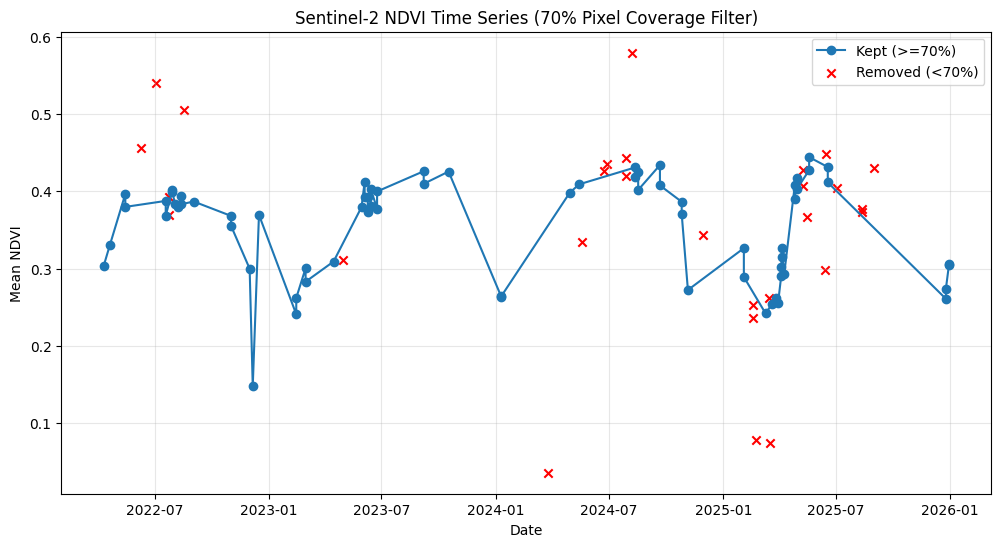

In [8]:
# Compute expected number of 10m pixels in ROI
roi_area_m2 = roi.area().getInfo()
pixel_area = 10 * 10
expected_pixels = roi_area_m2 / pixel_area

# 70% threshold
threshold = expected_pixels * 0.70

# Apply threshold
df = df_s2.copy()
df["min_required"] = threshold
df["status"] = np.where(df["n_pixels"] >= df["min_required"], "kept", "removed")

df_kept = df[df["status"] == "kept"].reset_index(drop=True)
df_removed = df[df["status"] == "removed"].reset_index(drop=True)

# Summary
summary = df.groupby("status").size().to_frame("count")
display(summary)

# Show removed rows
display(df_removed[["date", "ndvi", "n_pixels"]])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_kept["date"], df_kept["ndvi"], marker="o", label="Kept (>=70%)")

if len(df_removed) > 0:
    plt.scatter(df_removed["date"], df_removed["ndvi"], marker="x", color="red", label="Removed (<70%)")

plt.legend()
plt.xlabel("Date")
plt.ylabel("Mean NDVI")
plt.title("Sentinel‑2 NDVI Time Series (70% Pixel Coverage Filter)")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# ================================
# Maandelijkse aggregatie (nadat we pixels hebben gefilterd)
# ================================

# NDVI: gebruik alleen de "kept" beelden met voldoende dekking, filter op datum,
# en aggregeer dan naar maandelijks gemiddelde
df_s2_filtered = df_kept[
    (df_kept["date"] >= NDVI_START_DATE) & 
    (df_kept["date"] <= NDVI_END_DATE)
].copy()

df_s2_copy = df_s2_filtered.copy()
df_s2_copy["year_month"] = df_s2_copy["date"].dt.to_period("M")
df_s2_month = df_s2_copy.groupby("year_month").agg({
    "ndvi": "mean",
    "date": "first"
}).reset_index(drop=True)
df_s2_month = df_s2_month.rename(columns={"ndvi": "ndvi_month"})
print(f"NDVI data gefilterd (na pixelfilter): {len(df_kept)} -> {len(df_s2_filtered)} records ({len(df_s2_month)} maanden)")
print(f"NDVI data gefilterd: {len(df_s2)} -> {len(df_s2_filtered)} records ({len(df_s2_month)} maanden)")

# GW: filter op NDVI_START_DATE tot NDVI_END_DATE, haal data uit GroundwaterObs en aggregeer naar maandelijks
gw_filtered = gw[(gw.index >= NDVI_START_DATE) & (gw.index <= NDVI_END_DATE)].copy()

gw_month_df = gw_filtered.reset_index()
gw_month_df.columns = ["peil_datum_tijd", "peil_waarde_cm", "flag", "comment", "origin"]
gw_month_df["peil_datum_tijd"] = pd.to_datetime(gw_month_df["peil_datum_tijd"])
gw_month_df["year_month"] = gw_month_df["peil_datum_tijd"].dt.to_period("M")
gw_month = gw_month_df.groupby("year_month").agg({
    "peil_waarde_cm": "mean",
    "peil_datum_tijd": "first"
}).reset_index(drop=True)
gw_month = gw_month.rename(columns={"peil_waarde_cm": "gw_month"})

print(f"GW data gefilterd: {len(gw)} -> {len(gw_filtered)} records ({len(gw_month)} maanden)")

# Zet date kolom om naar datetime voor latere matching
gw_month["date"] = pd.to_datetime(gw_month["peil_datum_tijd"])
df_s2_month["date"] = pd.to_datetime(df_s2_month["date"])

display(df_s2_month)
display(gw_month)

NDVI data gefilterd (na pixelfilter): 71 -> 71 records (27 maanden)
NDVI data gefilterd: 99 -> 71 records (27 maanden)
GW data gefilterd: 9329 -> 8476 records (45 maanden)


,ndvi_month,date
0,0.316518,2022-04-10
1,0.388218,2022-05-15
2,0.389090,2022-07-19
3,0.384928,2022-08-03
4,0.386849,2022-09-02
5,0.361886,2022-11-01
6,0.272481,2022-12-01
7,0.251503,2023-02-14
8,0.291776,2023-03-01
9,0.309163,2023-04-15


,gw_month,peil_datum_tijd,date
0,-2.648611,2022-04-01 01:00:00,2022-04-01 01:00:00
1,-2.706624,2022-05-01 01:00:00,2022-05-01 01:00:00
2,-2.683989,2022-06-01 01:00:00,2022-06-01 01:00:00
3,-2.794995,2022-07-01 01:00:00,2022-07-01 01:00:00
4,-2.898860,2022-08-01 01:00:00,2022-08-01 01:00:00
5,-2.783450,2022-09-01 01:00:00,2022-09-01 01:00:00
6,-2.755720,2022-10-01 01:00:00,2022-10-01 01:00:00
7,-2.692017,2022-11-01 01:00:00,2022-11-01 01:00:00
8,-2.675382,2022-12-01 01:00:00,2022-12-01 01:00:00
9,-2.566790,2023-01-01 01:00:00,2023-01-01 01:00:00


Periode: 2022-04-1 tot 2025-12-31
Verwacht aantal maanden: 45

--- Data beschikbaarheid ---
Werkelijke maanden in analyse: 45
Waarvan NDVI geïnterpoleerd: 18 keer
Waarvan GW geïnterpoleerd: 0 keer


,date,ndvi_month,gw_month,ndvi_interpolated,gw_interpolated
0,2022-04-10 00:00:00,0.316518,-2.648611,False,False
1,2022-05-15 00:00:00,0.388218,-2.706624,False,False
2,2022-06-01 01:00:00,0.388654,-2.683989,True,False
3,2022-07-19 00:00:00,0.389090,-2.794995,False,False
4,2022-08-03 00:00:00,0.384928,-2.898860,False,False
5,2022-09-02 00:00:00,0.386849,-2.783450,False,False
6,2022-10-01 01:00:00,0.374368,-2.755720,True,False
7,2022-11-01 00:00:00,0.361886,-2.692017,False,False
8,2022-12-01 00:00:00,0.272481,-2.675382,False,False
9,2023-01-01 01:00:00,0.261992,-2.566790,True,False



OLS LINEAIRE REGRESSIE RESULTATEN
                            OLS Regression Results                            
Dep. Variable:             ndvi_month   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     7.797
Date:                Sun, 29 Mar 2026   Prob (F-statistic):            0.00778
Time:                        23:37:41   Log-Likelihood:                 70.289
No. Observations:                  45   AIC:                            -136.6
Df Residuals:                      43   BIC:                            -133.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.

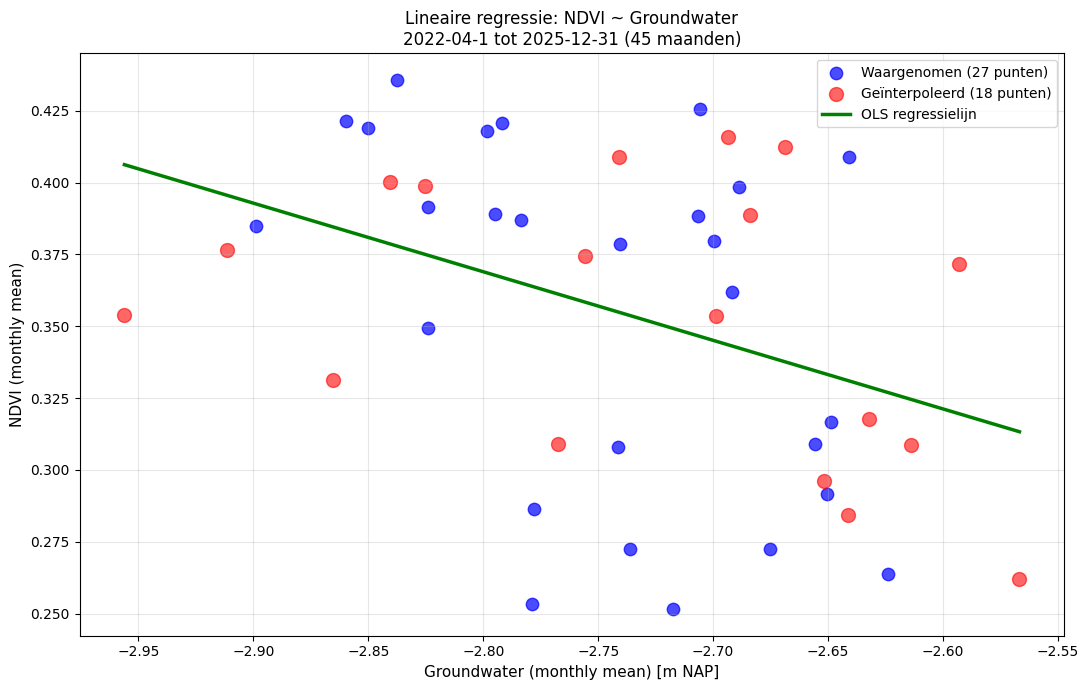

In [10]:
# ================================
# Voorbereiding en merging
# ================================

# Bereken het aantal verwachte maanden uit NDVI_START_DATE en NDVI_END_DATE
start_dt = pd.to_datetime(NDVI_START_DATE)
end_dt = pd.to_datetime(NDVI_END_DATE)
expected_months = (end_dt.year - start_dt.year) * 12 + (end_dt.month - start_dt.month) + 1

print(f"Periode: {NDVI_START_DATE} tot {NDVI_END_DATE}")
print(f"Verwacht aantal maanden: {expected_months}")

# Zet beide dates om naar YYYY-MM formaat voor matching
gw_month["date_period"] = gw_month["date"].dt.to_period("M")
df_s2_month["date_period"] = df_s2_month["date"].dt.to_period("M")

# Merge NDVI en GW op period
df_month = (
    df_s2_month.merge(gw_month[["gw_month", "date_period", "date"]],
                      left_on="date_period", right_on="date_period", how="outer")
    .sort_values("date_x")
    .reset_index(drop=True)
)

# Vul datumkolom
df_month["date"] = df_month["date_x"].fillna(df_month["date_y"])
df_month = df_month.drop(columns=["date_x", "date_y"])

# BELANGRIJK: Sorteer op datum VOORDAT interpolatie
df_month = df_month.sort_values("date").reset_index(drop=True)

# ================================
# Interpolatie
# ================================

# Track welke waarden geïnterpoleerd zijn VOORDAT we interpoleren
df_month["ndvi_interpolated"] = df_month["ndvi_month"].isna()
df_month["gw_interpolated"] = df_month["gw_month"].isna()

# Interpoleer beide kolommen (nu correct gesorteerd op datum)
df_month["ndvi_month"] = df_month["ndvi_month"].interpolate(method="linear")
df_month["gw_month"] = df_month["gw_month"].interpolate(method="linear")

# Verwijder ALLEEN de edges met NaN (voor en na de reeks)
df_month = df_month.dropna(subset=["ndvi_month", "gw_month"]).reset_index(drop=True)

actual_months = len(df_month)

print(f"\n--- Data beschikbaarheid ---")
print(f"Werkelijke maanden in analyse: {actual_months}")
print(f"Waarvan NDVI geïnterpoleerd: {df_month['ndvi_interpolated'].sum()} keer")
print(f"Waarvan GW geïnterpoleerd: {df_month['gw_interpolated'].sum()} keer")

display(df_month[["date", "ndvi_month", "gw_month", "ndvi_interpolated", "gw_interpolated"]])

# ================================
# 1) Data voorbereiden
# ================================

X = df_month[["gw_month"]]     # onafhankelijke variabele
X = sm.add_constant(X)         # voeg intercept toe
y = df_month["ndvi_month"]     # afhankelijke variabele

# ================================
# 2) OLS-regressie fitten
# ================================

ols_model = sm.OLS(y, X).fit()

print("\n==============================================")
print("OLS LINEAIRE REGRESSIE RESULTATEN")
print("==============================================")
print(ols_model.summary())

# ================================
# 3) Scatterplot + regressielijn
# ================================

plt.figure(figsize=(11, 7))

is_obs = ~(df_month["ndvi_interpolated"] | df_month["gw_interpolated"])

plt.scatter(df_month.loc[is_obs, "gw_month"], df_month.loc[is_obs, "ndvi_month"],
            label=f"Waargenomen ({is_obs.sum()} punten)", marker="o", s=80, alpha=0.7, color="blue")

plt.scatter(df_month.loc[~is_obs, "gw_month"], df_month.loc[~is_obs, "ndvi_month"],
            label=f"Geïnterpoleerd ({(~is_obs).sum()} punten)", marker="o", s=100, color="red", alpha=0.6)

# Regressielijn
xline = np.linspace(df_month["gw_month"].min(), df_month["gw_month"].max(), 100)
xline_const = sm.add_constant(xline)
plt.plot(xline, ols_model.predict(xline_const), color="green", linewidth=2.5, label="OLS regressielijn")

plt.xlabel("Groundwater (monthly mean) [m NAP]", fontsize=11)
plt.ylabel("NDVI (monthly mean)", fontsize=11)
plt.title(f"Lineaire regressie: NDVI ~ Groundwater\n{NDVI_START_DATE} tot {NDVI_END_DATE} ({actual_months} maanden)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### ARDL(1,1) Summary
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ndvi_month   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     16.41
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           4.17e-07
Time:                        23:37:50   Log-Likelihood:                 82.457
No. Observations:                  44   AIC:                            -156.9
Df Residuals:                      40   BIC:                            -149.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0664      0.199     -0.334      0.740      -0.468       0.336
gw_month      -0.1138      0.090     -1.268      0.212      -0.295       0.068
gw_lag1        0.0517      0.091      0.569      0.573      -0.132       0.235
ndvi_lag1      0.7055      0.119      5.951      0.000       0.466       0.945
==============================================================================
Omnibus:                        2.251   Durbin-Watson:                   1.347
Prob(Omnibus):                  0.324   Jarque-Bera (JB):                1.440
Skew:                          -0.424   Prob(JB):                        0.487
Kurtosis:                       3.260   Cond. No.                         143.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
```

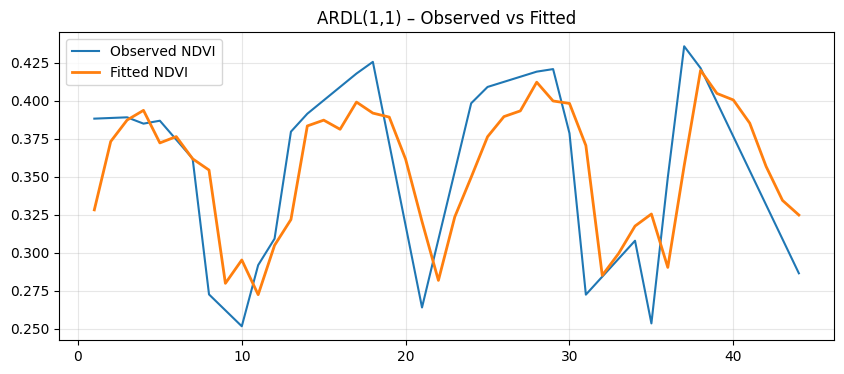

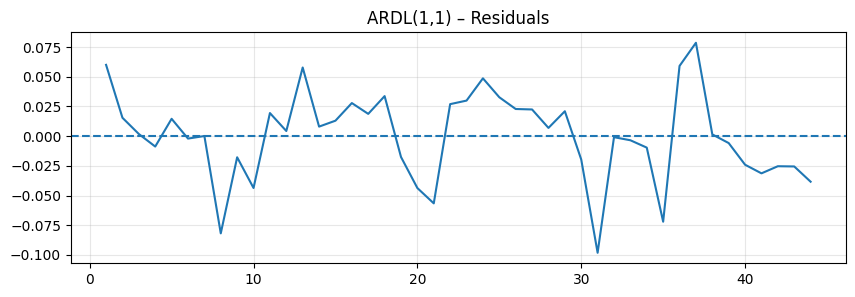

### ARDL(2,2) Summary
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ndvi_month   R-squared:                       0.695
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     16.85
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           1.15e-08
Time:                        23:37:50   Log-Likelihood:                 88.533
No. Observations:                  43   AIC:                            -165.1
Df Residuals:                      37   BIC:                            -154.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0707      0.187      0.379      0.707      -0.308       0.449
gw_month      -0.0281      0.080     -0.352      0.726      -0.189       0.133
gw_lag1       -0.1326      0.097     -1.373      0.178      -0.328       0.063
gw_lag2        0.1376      0.078      1.762      0.086      -0.021       0.296
ndvi_lag1      1.0323      0.142      7.275      0.000       0.745       1.320
ndvi_lag2     -0.4153      0.143     -2.900      0.006      -0.705      -0.125
==============================================================================
Omnibus:                        5.818   Durbin-Watson:                   2.163
Prob(Omnibus):                  0.055   Jarque-Bera (JB):                4.756
Skew:                          -0.584   Prob(JB):                       0.0927
Kurtosis:                       4.137   Cond. No.                         191.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
```

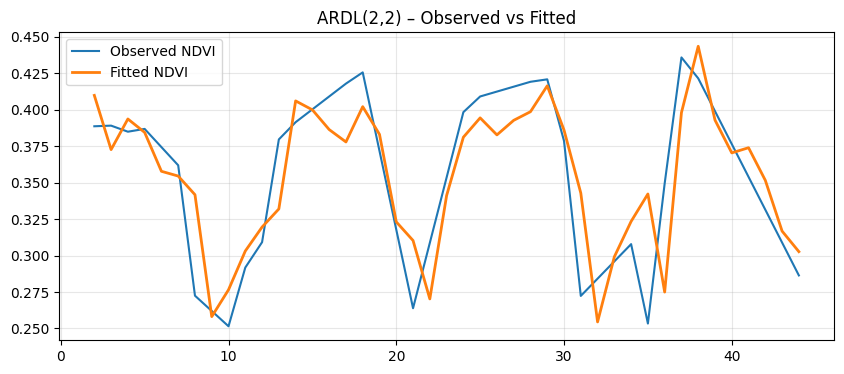

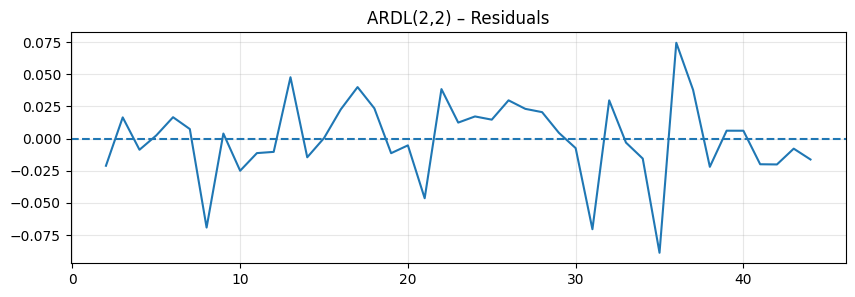

### ARDL(3,3) Summary
```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ndvi_month   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:                     12.16
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           1.16e-07
Time:                        23:37:51   Log-Likelihood:                 87.569
No. Observations:                  42   AIC:                            -159.1
Df Residuals:                      34   BIC:                            -145.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1963      0.206      0.952      0.348      -0.223       0.615
gw_month      -0.0252      0.081     -0.309      0.759      -0.191       0.140
gw_lag1       -0.1180      0.099     -1.188      0.243      -0.320       0.084
gw_lag2        0.0535      0.100      0.532      0.598      -0.151       0.258
gw_lag3        0.1077      0.084      1.274      0.211      -0.064       0.279
ndvi_lag1      0.9480      0.173      5.492      0.000       0.597       1.299
ndvi_lag2     -0.2620      0.227     -1.155      0.256      -0.723       0.199
ndvi_lag3     -0.1056      0.160     -0.662      0.513      -0.430       0.219
==============================================================================
Omnibus:                        7.835   Durbin-Watson:                   2.211
Prob(Omnibus):                  0.020   Jarque-Bera (JB):                6.913
Skew:                          -0.762   Prob(JB):                       0.0315
Kurtosis:                       4.276   Cond. No.                         321.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
```

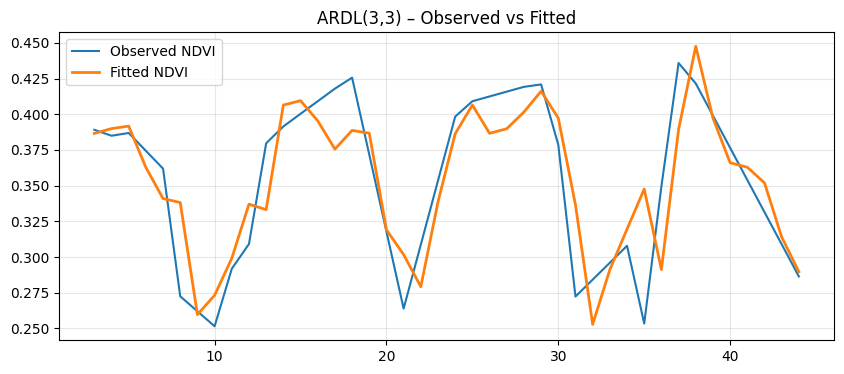

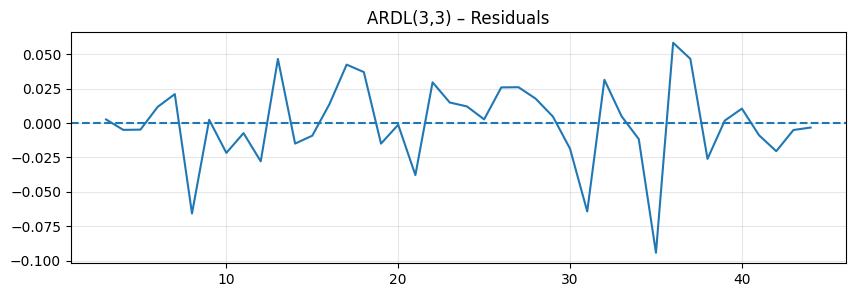

In [11]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

results = []
metrics = []

for p in [1, 2, 3]:
    q = p  # ARDL(p,p)

    df_lagged = df_month.sort_index().copy()

    # NDVI lags
    for i in range(1, p+1):
        df_lagged[f"ndvi_lag{i}"] = df_lagged["ndvi_month"].shift(i)

    # GW lags
    for j in range(1, q+1):
        df_lagged[f"gw_lag{j}"] = df_lagged["gw_month"].shift(j)

    # Drop missings
    df_lagged = df_lagged.dropna()

    # ===== BELANGRIJK: huidige GW_t toevoegen =====
    lag_cols = ["gw_month"] + \
               [f"gw_lag{j}" for j in range(1, q+1)] + \
               [f"ndvi_lag{i}" for i in range(1, p+1)]

    X = sm.add_constant(df_lagged[lag_cols])
    y = df_lagged["ndvi_month"]

    model = sm.OLS(y, X).fit()
    results.append((p, q, model))

    summary_text = model.summary().as_text()
    display(Markdown(f"### ARDL({p},{q}) Summary\n```\n{summary_text}\n```"))

    metrics.append({
        "Model": f"ARDL({p},{q})",
        "R²": round(model.rsquared, 3),
        "Adj R²": round(model.rsquared_adj, 3),
        "AIC": round(model.aic, 2),
        "BIC": round(model.bic, 2)
    })

    plt.figure(figsize=(10, 4))
    plt.plot(df_lagged.index, y, label="Observed NDVI")
    plt.plot(df_lagged.index, model.fittedvalues, label="Fitted NDVI", linewidth=2)
    plt.title(f"ARDL({p},{q}) – Observed vs Fitted")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(df_lagged.index, model.resid)
    plt.axhline(0, linestyle="--")
    plt.title(f"ARDL({p},{q}) – Residuals")
    plt.grid(alpha=0.3)
    plt.show()

                            OLS Regression Results                            
Dep. Variable:             ndvi_month   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.526
Method:                 Least Squares   F-statistic:                     24.87
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           8.46e-08
Time:                        23:38:00   Log-Likelihood:                 82.280
No. Observations:                  44   AIC:                            -158.6
Df Residuals:                      41   BIC:                            -153.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1141      0.179     -0.638      0.5

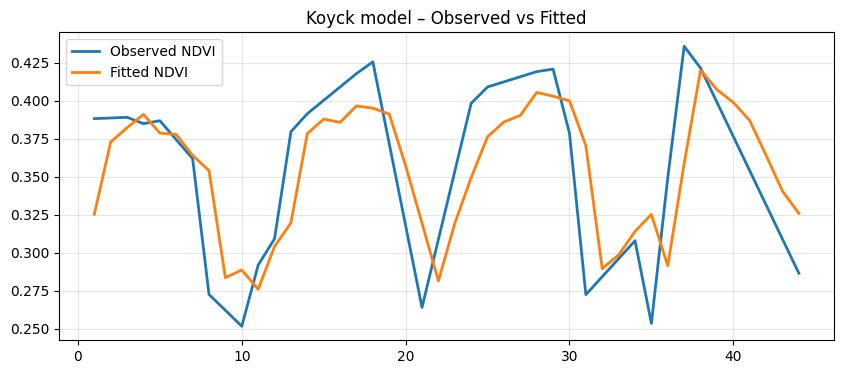

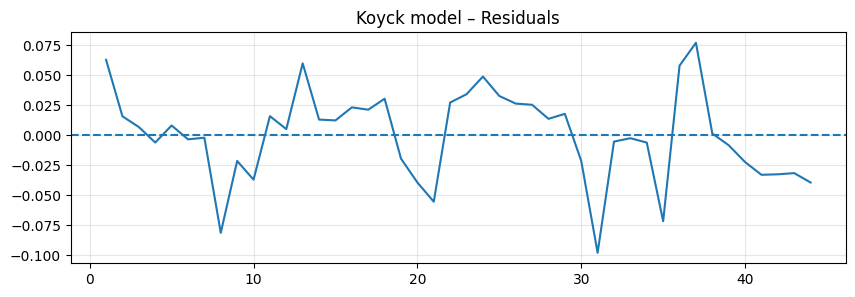

In [12]:
df_koyck = df_month.sort_index().copy()

df_koyck["ndvi_lag1"] = df_koyck["ndvi_month"].shift(1)

df_koyck = df_koyck.dropna(subset=["ndvi_lag1", "gw_month", "ndvi_month"])

y = df_koyck["ndvi_month"]
X = df_koyck[["gw_month", "ndvi_lag1"]]   # huidige GW + NDVI lag
X = sm.add_constant(X)

koyck_model = sm.OLS(y, X).fit()
print(koyck_model.summary())

plt.figure(figsize=(10,4))
plt.plot(df_koyck.index, y, label="Observed NDVI", linewidth=2)
plt.plot(df_koyck.index, koyck_model.fittedvalues, label="Fitted NDVI", linewidth=2)
plt.title("Koyck model – Observed vs Fitted")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(df_koyck.index, koyck_model.resid)
plt.axhline(0, linestyle="--")
plt.title("Koyck model – Residuals")
plt.grid(alpha=0.3)
plt.show()

In [13]:
summary_rows = []

# ============================================

# 1) LINEAIRE REGRESSIE

# ============================================

summary_rows.append({

    "Model": "Linear Regression",

    "R²": ols_model.rsquared,

    "Adj R²": ols_model.rsquared_adj,

    "Prob(F)": ols_model.f_pvalue,

    "F-statistic": ols_model.fvalue,

    "AIC": ols_model.aic,

    "BIC": ols_model.bic

})

# ============================================

# 2) ARDL MODELLEN

# ============================================

for (p, q, model) in results:

    summary_rows.append({

        "Model": f"ARDL({p},{q})",

        "R²": model.rsquared,

        "Adj R²": model.rsquared_adj,

        "Prob(F)": model.f_pvalue,

        "F-statistic": model.fvalue,

        "AIC": model.aic,

        "BIC": model.bic

    })

# ============================================

# 3) KOYCK

# ============================================

summary_rows.append({

    "Model": "Koyck Transformation",

    "R²": koyck_model.rsquared,

    "Adj R²": koyck_model.rsquared_adj,

    "Prob(F)": koyck_model.f_pvalue,

    "F-statistic": koyck_model.fvalue,

    "AIC": koyck_model.aic,

    "BIC": koyck_model.bic

})

summary_df = pd.DataFrame(summary_rows).round(4)

display(summary_df)

,Model,R²,Adj R²,Prob(F),F-statistic,AIC,BIC
0,Linear Regression,0.1535,0.1338,0.0078,7.7972,-136.5774,-132.9641
1,"ARDL(1,1)",0.5518,0.5182,0.0000,16.4133,-156.9144,-149.7777
2,"ARDL(2,2)",0.6948,0.6536,0.0000,16.8500,-165.0651,-154.4979
3,"ARDL(3,3)",0.7145,0.6558,0.0000,12.1584,-159.1375,-145.2361
4,Koyck Transformation,0.5481,0.5261,0.0000,24.8683,-158.5597,-153.2071


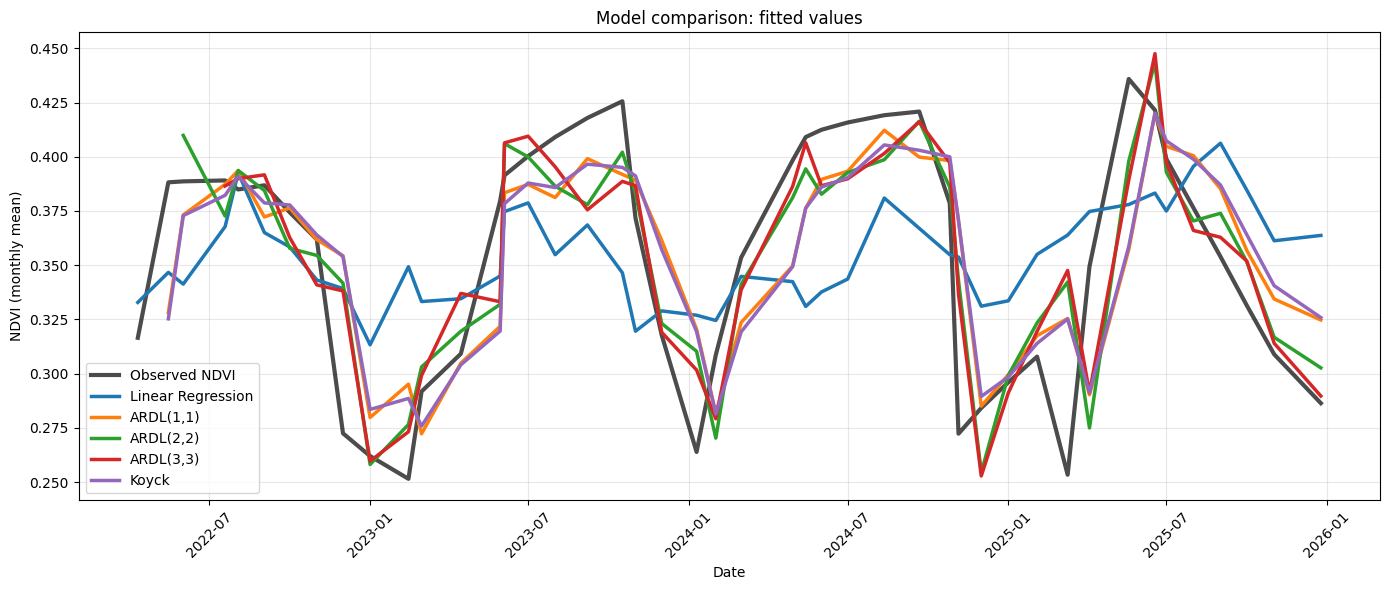

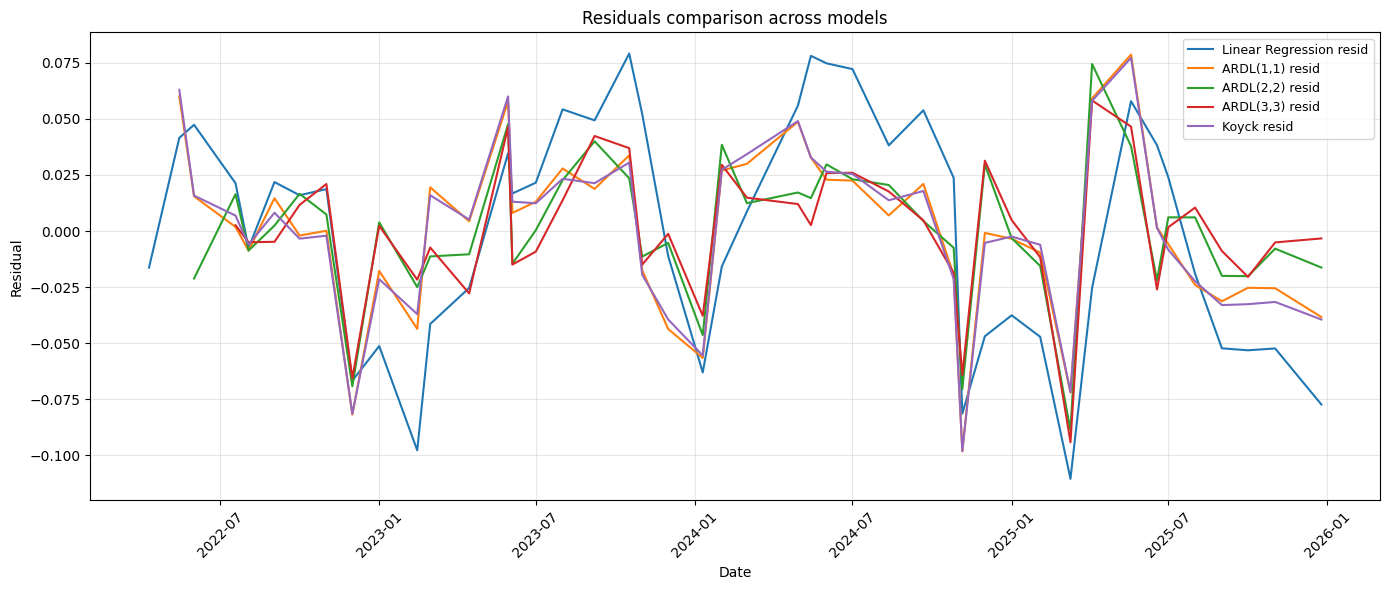


Model comparison summary:


,Model,R²,Adj R²,Prob(F),F-statistic,AIC,BIC
0,Linear Regression,0.1535,0.1338,0.0078,7.7972,-136.5774,-132.9641
1,"ARDL(1,1)",0.5518,0.5182,0.0000,16.4133,-156.9144,-149.7777
2,"ARDL(2,2)",0.6948,0.6536,0.0000,16.8500,-165.0651,-154.4979
3,"ARDL(3,3)",0.7145,0.6558,0.0000,12.1584,-159.1375,-145.2361
4,Koyck Transformation,0.5481,0.5261,0.0000,24.8683,-158.5597,-153.2071


In [13]:
# ================================
# Combined fit & residual comparison
# ================================

# Prepare color palette
colors = {
    'ols': '#1f77b4',
    'ardl_1_1': '#ff7f0e',
    'ardl_2_2': '#2ca02c',
    'ardl_3_3': '#d62728',
    'koyck': '#9467bd'
}

# combined fitted plot
fig, ax = plt.subplots(figsize=(14,6))

# observed NDVI line
ax.plot(df_month['date'], df_month['ndvi_month'], color='black', linewidth=3, alpha=0.7, label='Observed NDVI')

# OLS fit
ols_dates = df_month.loc[ols_model.fittedvalues.index, 'date'].values
ax.plot(ols_dates, ols_model.fittedvalues.values, color=colors['ols'], linewidth=2.5, label='Linear Regression')

# ARDL fits
for p,q,model in results:
    key = f'ardl_{p}_{q}'
    dates = df_month.loc[model.fittedvalues.index, 'date'].values
    ax.plot(dates, model.fittedvalues.values, color=colors[key], linewidth=2.5, label=f'ARDL({p},{q})')

# Koyck fit
koyck_dates = df_koyck.loc[koyck_model.fittedvalues.index, 'date'].values
ax.plot(koyck_dates, koyck_model.fittedvalues.values, color=colors['koyck'], linewidth=2.5, label='Koyck')

ax.set_xlabel('Date')
ax.set_ylabel('NDVI (monthly mean)')
ax.set_title('Model comparison: fitted values')
ax.legend(loc='best', fontsize=10)
ax.grid(True,alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# residual comparison
fig, ax = plt.subplots(figsize=(14,6))

# OLS residuals
ols_dates = df_month.loc[ols_model.resid.index, 'date'].values
ax.plot(ols_dates, ols_model.resid.values, color=colors['ols'], linewidth=1.5, label='Linear Regression resid')

for p,q,model in results:
    key = f'ardl_{p}_{q}'
    dates = df_month.loc[model.resid.index, 'date'].values
    ax.plot(dates, model.resid.values, color=colors[key], linewidth=1.5, label=f'ARDL({p},{q}) resid')

# Koyck residuals
koyck_dates = df_koyck.loc[koyck_model.resid.index, 'date'].values
ax.plot(koyck_dates, koyck_model.resid.values, color=colors['koyck'], linewidth=1.5, label='Koyck resid')

ax.set_xlabel('Date')
ax.set_ylabel('Residual')
ax.set_title('Residuals comparison across models')
ax.legend(fontsize=9)
ax.grid(True,alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# display existing summary table again for reference
print('\nModel comparison summary:')
display(summary_df)

In [14]:
# ────────────────────────────────────────────────
#  Laad de gesimuleerde grondwaterstanden (forecast)
# ────────────────────────────────────────────────
import pandas as pd

path = r"C:\afstuderen\python_projects\beroepsproduct\three_scenarios_forecast.csv"

# Lees de CSV met de datum als index (eerste kolom zonder header-naam)
df_forecast = pd.read_csv(
    path,
    index_col=0,           # de eerste kolom (datums) wordt de index
    parse_dates=True       # probeer automatisch datums te parsen
)

# Hernoem kolommen naar duidelijke namen (past bij je eerdere code)
df_forecast = df_forecast.rename(columns={
    'Mean':   'gw_mean_sim',
    'Upper':  'gw_upper_95',
    'Lower':  'gw_lower_5'
})

# Zorg ervoor dat de index écht datetime is
if not pd.api.types.is_datetime64_any_dtype(df_forecast.index):
    df_forecast.index = pd.to_datetime(df_forecast.index)

# Controleer of alles goed is ingelezen
print("Bestand succesvol ingelezen!")
print("Vorm van de DataFrame:", df_forecast.shape)
print("Index type:", df_forecast.index.dtype)
print("Eerste datum:", df_forecast.index.min())
print("Laatste datum:", df_forecast.index.max())
print("Kolommen:", df_forecast.columns.tolist())

# Toon de eerste 10 rijen + laatste 5 rijen
print("\nVoorbeeld data (eerste 10 dagen):")
display(df_forecast.head(10))

print("\nLaatste 5 dagen:")
display(df_forecast.tail(5))

# Optioneel: sla een nette versie op met datum als kolom (voor later gebruik)
df_forecast_reset = df_forecast.reset_index().rename(columns={'index': 'Date'})
df_forecast_reset.to_csv(
    r"C:\afstuderen\python_projects\beroepsproduct\three_scenarios_forecast.csv",
    index=False,
    float_format="%.6f"
)
print("\nSchone versie opgeslagen met 'Date'-kolom → three_scenarios_forecast.csv")

Bestand succesvol ingelezen!
Vorm van de DataFrame: (213, 3)
Index type: datetime64[ns]
Eerste datum: 2025-09-01 00:00:00
Laatste datum: 2026-04-01 00:00:00
Kolommen: ['gw_mean_sim', 'gw_upper_95', 'gw_lower_5']

Voorbeeld data (eerste 10 dagen):


,gw_mean_sim,gw_upper_95,gw_lower_5
Date,,,
2025-09-01,-2.842409,-2.838941,-2.843679
2025-09-02,-2.842320,-2.838740,-2.844617
2025-09-03,-2.842222,-2.836396,-2.845546
2025-09-04,-2.841492,-2.832593,-2.845770
2025-09-05,-2.840605,-2.822508,-2.846764
2025-09-06,-2.839854,-2.821888,-2.847009
2025-09-07,-2.839496,-2.820799,-2.847764
2025-09-08,-2.839094,-2.820711,-2.848589
2025-09-09,-2.838172,-2.821008,-2.849099



Laatste 5 dagen:


,gw_mean_sim,gw_upper_95,gw_lower_5
Date,,,
2026-03-28,-2.722425,-2.681783,-2.748648
2026-03-29,-2.722667,-2.680811,-2.749794
2026-03-30,-2.723286,-2.682005,-2.750522
2026-03-31,-2.723782,-2.681641,-2.751115
2026-04-01,-2.723877,-2.681904,-2.751104



Schone versie opgeslagen met 'Date'-kolom → three_scenarios_forecast.csv


→ ARDL(3,3)
Voorspellen scenario: mean
Voorspellen scenario: upper
Voorspellen scenario: lower
Waargenomen NDVI na pixelfilter, deduplicatie per dag en maandaggregatie:


,year_month,ndvi_month,date,n_obs
0,2025-12,0.286316,2025-12-25,2
1,2026-01,0.308103,2026-01-14,2
2,2026-03,0.280371,2026-03-05,2


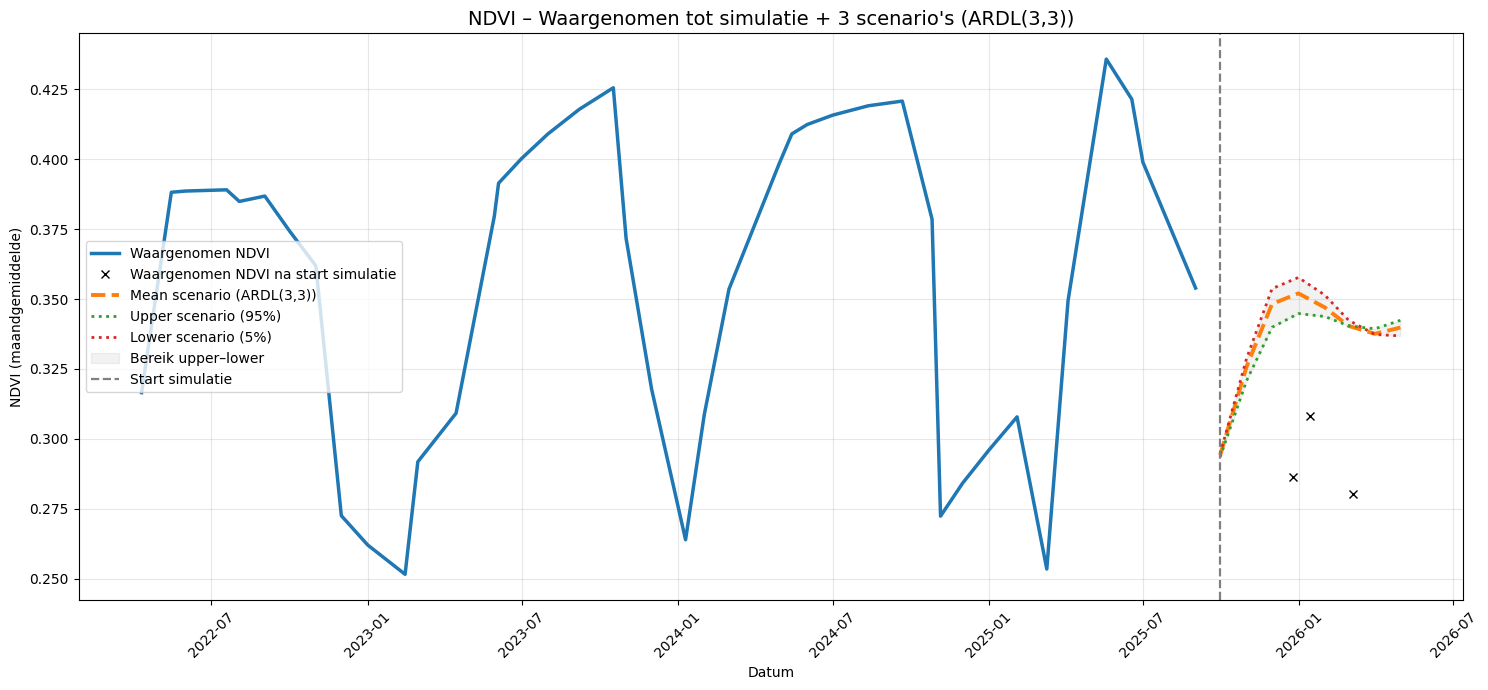


Laatste 6 maanden voorspelling – ARDL(3,3)


,date,ndvi_mean,ndvi_upper,ndvi_lower
2,2025-11-30,0.3483,0.3399,0.3537
3,2025-12-31,0.3520,0.3448,0.3577
4,2026-01-31,0.3470,0.3438,0.3514
5,2026-02-28,0.3404,0.3404,0.3425
6,2026-03-31,0.3376,0.3394,0.3373
7,2026-04-30,0.3398,0.3424,0.3368


In [18]:
# ────────────────────────────────────────────────
#  NDVI voorspellen PER SCENARIO + plot met 3 lijnen
#  Waargenomen NDVI na start simulatie: eerst dedupliceren per dag,
#  daarna aggregeren naar maandgemiddelde
# ────────────────────────────────────────────────
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

# ================================================
# Welk model wil je gebruiken?
# ================================================
model_choice = "ARDL(3,3)"          # Voorbeelden: "linear", "koyck", "ARDL(1,1)", "ARDL(2,2)", "ARDL(3,3)"

# ================================================
# Maandelijkse GW forecast voorbereiden
# ================================================
df_forecast_month = df_forecast.resample("ME").mean(numeric_only=True)
df_forecast_month["date"] = df_forecast_month.index
df_forecast_month = df_forecast_month.reset_index(drop=True)

# Startdatum van de simulatie/forecast
forecast_start = df_forecast_month["date"].min()

# ================================================
# Model selecteren
# ================================================
model = None
use_lagged_ndvi = False
p, q = 0, 0

if model_choice == "linear":
    model = ols_model
    use_lagged_ndvi = False
    print("→ Linear regression (OLS)")

elif model_choice == "koyck":
    model = koyck_model
    use_lagged_ndvi = True
    p, q = 1, 1   # koyck ≈ ARDL(1,1)
    print("→ Koyck model")

elif model_choice.startswith("ARDL("):
    try:
        p_str, q_str = model_choice.replace("ARDL(", "").replace(")", "").split(",")
        p = int(p_str.strip())
        q = int(q_str.strip())

        for pp, qq, m in results:
            if pp == p and qq == q:
                model = m
                break

        if model is None:
            raise ValueError(f"ARDL({p},{q}) niet gevonden in results")

        use_lagged_ndvi = True
        print(f"→ ARDL({p},{q})")

    except Exception as e:
        print(f"Fout bij ARDL: {e}")
        raise

else:
    raise ValueError("Onbekend model. Gebruik 'linear', 'koyck' of 'ARDL(p,q)'")

# ================================================
# Drie scenario's voorspellen
# ================================================
scenarios = ["mean", "upper", "lower"]
ndvi_preds = {}

for scen in scenarios:
    print(f"Voorspellen scenario: {scen}")

    if not use_lagged_ndvi:
        # Directe voorspelling (alleen bij linear model)
        gw_col = "gw_mean_sim" if scen == "mean" else f"gw_{scen}_95" if scen == "upper" else "gw_lower_5"
        X_scen = sm.add_constant(df_forecast_month[gw_col])
        ndvi_preds[scen] = model.predict(X_scen)

    else:
        # Recursieve voorspelling PER SCENARIO
        forecast_ndvi = []

        # Start met historische waarden (zelfde voor alle scenario's)
        ndvi_history = list(df_month["ndvi_month"].tail(max(p, 1)).values[::-1])
        gw_history = list(df_month["gw_month"].tail(max(q, 1)).values[::-1])

        gw_col = "gw_mean_sim" if scen == "mean" else f"gw_{scen}_95" if scen == "upper" else "gw_lower_5"

        for _, row in df_forecast_month.iterrows():
            X_dict = {"const": 1.0}

            current_gw = row[gw_col]
            X_dict["gw_month"] = current_gw

            # GW lags
            for lag in range(1, q + 1):
                val = gw_history[lag - 1] if len(gw_history) >= lag else df_month["gw_month"].iloc[-1]
                X_dict[f"gw_lag{lag}"] = val

            # NDVI lags (uit dit scenario)
            for lag in range(1, p + 1):
                val = ndvi_history[lag - 1] if len(ndvi_history) >= lag else df_month["ndvi_month"].iloc[-1]
                X_dict[f"ndvi_lag{lag}"] = val

            X_row = pd.DataFrame([X_dict])
            pred = model.predict(X_row)[0]
            forecast_ndvi.append(pred)

            ndvi_history.insert(0, pred)
            gw_history.insert(0, current_gw)

        ndvi_preds[scen] = forecast_ndvi

# Resultaten toevoegen aan dataframe
df_forecast_month["ndvi_mean"] = ndvi_preds["mean"]
df_forecast_month["ndvi_upper"] = ndvi_preds["upper"]
df_forecast_month["ndvi_lower"] = ndvi_preds["lower"]

# Laad waargenomen NDVI opnieuw in vanaf start simulatie met dezelfde filters
actual_end_date = pd.Timestamp.today().normalize().strftime("%Y-%m-%d")
df_s2_actual = ndvi_timeseries(
    collection_id="COPERNICUS/S2_SR_HARMONIZED",
    roi=roi,
    start_date=forecast_start.strftime("%Y-%m-%d"),
    end_date=actual_end_date,
    scale=10,
    add_ndvi_fn=add_ndvi_s2,
    mask_fn=mask_s2_clouds,
    extra_filter=ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30),
)
df_s2_actual = df_s2_actual[df_s2_actual["n_pixels"] >= threshold].copy()

df_s2_actual_month = pd.DataFrame(columns=["date", "ndvi_month"])
if not df_s2_actual.empty:
    # Dedupliceer eerst per dag, omdat dezelfde datum meerdere Sentinel-tiles kan bevatten.
    df_s2_actual_daily = (
        df_s2_actual.assign(
            weight=df_s2_actual["n_pixels"],
            weighted_ndvi=df_s2_actual["ndvi"] * df_s2_actual["n_pixels"],
        )
        .groupby("date", as_index=False)
        .agg(
            weighted_ndvi_sum=("weighted_ndvi", "sum"),
            total_pixels=("weight", "sum"),
        )
    )
    df_s2_actual_daily["ndvi"] = (
        df_s2_actual_daily["weighted_ndvi_sum"] / df_s2_actual_daily["total_pixels"]
    )

    # Daarna naar maandniveau, zodat observaties vergelijkbaar zijn met de maandelijkse forecast.
    df_s2_actual_daily["year_month"] = df_s2_actual_daily["date"].dt.to_period("M")
    df_s2_actual_month = (
        df_s2_actual_daily.groupby("year_month", as_index=False)
        .agg(
            ndvi_month=("ndvi", "mean"),
            date=("date", "min"),
            n_obs=("ndvi", "size"),
        )
        .sort_values("date")
        .reset_index(drop=True)
    )
    print("Waargenomen NDVI na pixelfilter, deduplicatie per dag en maandaggregatie:")
    display(df_s2_actual_month)

# ================================================
# Plot: historische NDVI + maandelijkse observaties + forecast
# ================================================
fig, ax = plt.subplots(figsize=(15, 7))

# Historische NDVI – alleen tot forecast start
hist_mask = df_month["date"] < forecast_start
ax.plot(df_month.loc[hist_mask, "date"],
        df_month.loc[hist_mask, "ndvi_month"],
        color="#1f77b4", linewidth=2.5, label="Waargenomen NDVI")

# Geaggregeerde waarnemingen vanaf start simulatie
if not df_s2_actual_month.empty:
    ax.plot(df_s2_actual_month["date"],
            df_s2_actual_month["ndvi_month"],
            marker="x",
            ls="",
            color="k",
            label="Waargenomen NDVI na start simulatie")

# Voorspelde lijnen – alleen in forecast-periode
fc_mask = df_forecast_month["date"] >= forecast_start

ax.plot(df_forecast_month.loc[fc_mask, "date"],
        df_forecast_month.loc[fc_mask, "ndvi_mean"],
        color="#ff7f0e", linewidth=2.8, linestyle="--", label=f"Mean scenario ({model_choice})")

ax.plot(df_forecast_month.loc[fc_mask, "date"],
        df_forecast_month.loc[fc_mask, "ndvi_upper"],
        color="#2ca02c", linewidth=2.0, linestyle=":", label="Upper scenario (95%)")

ax.plot(df_forecast_month.loc[fc_mask, "date"],
        df_forecast_month.loc[fc_mask, "ndvi_lower"],
        color="#d62728", linewidth=2.0, linestyle=":", label="Lower scenario (5%)")

# Band alleen in forecast-periode
ax.fill_between(df_forecast_month.loc[fc_mask, "date"],
                df_forecast_month.loc[fc_mask, "ndvi_lower"],
                df_forecast_month.loc[fc_mask, "ndvi_upper"],
                color="gray", alpha=0.10, label="Bereik upper–lower")

# Scheidingslijn
ax.axvline(forecast_start, color="gray", linestyle="--", linewidth=1.6,
           label="Start simulatie")

ax.set_ylabel("NDVI (maandgemiddelde)")
ax.set_xlabel("Datum")
ax.set_title(f"NDVI – Waargenomen tot simulatie + 3 scenario's ({model_choice})", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Laatste paar voorspellingen tonen
print(f"\nLaatste 6 maanden voorspelling – {model_choice}")
display(df_forecast_month[["date", "ndvi_mean", "ndvi_upper", "ndvi_lower"]].tail(6).round(4))

,year_month,ndvi_observed,ndvi_mean,ndvi_upper,ndvi_lower,difference_obs_minus_sim,abs_difference
0,2025-12,0.2863,0.3520,0.3448,0.3577,-0.0657,0.0657
1,2026-01,0.3081,0.3470,0.3438,0.3514,-0.0389,0.0389
2,2026-03,0.2804,0.3376,0.3394,0.3373,-0.0572,0.0572


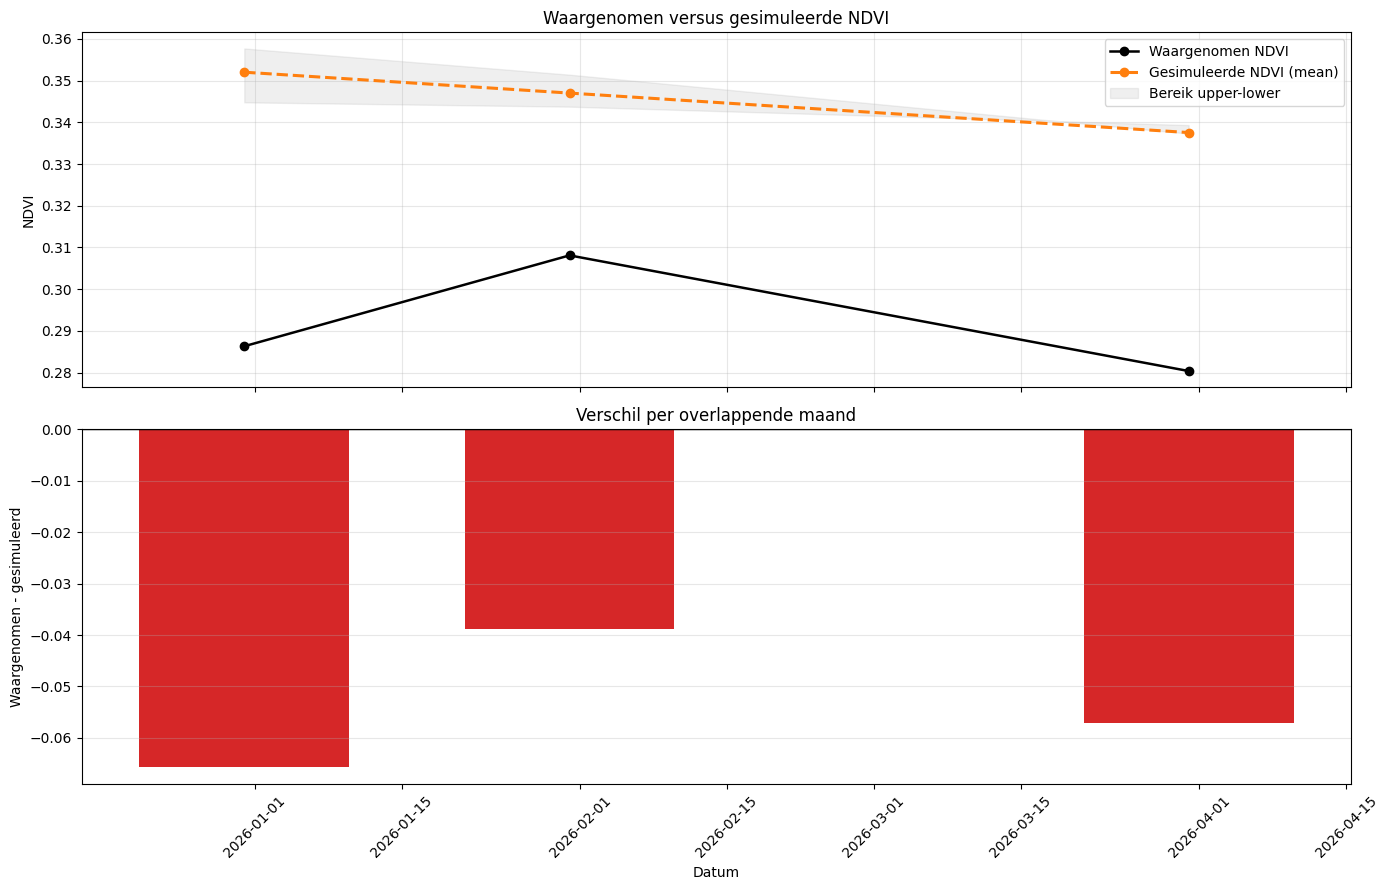

Gemiddeld verschil (waargenomen - gesimuleerd): -0.0539
Gemiddelde absolute afwijking: 0.0539


In [19]:
# Vergelijk waargenomen NDVI met gesimuleerde NDVI in de overlapperiode
if df_s2_actual_month.empty:
    print("Geen waargenomen NDVI beschikbaar na start simulatie.")
else:
    comparison_df = df_s2_actual_month[["year_month", "date", "ndvi_month"]].rename(
        columns={"date": "observed_date", "ndvi_month": "ndvi_observed"}
    )

    simulated_df = df_forecast_month.copy()
    simulated_df["year_month"] = simulated_df["date"].dt.to_period("M")
    simulated_df = simulated_df[["year_month", "date", "ndvi_mean", "ndvi_upper", "ndvi_lower"]].rename(
        columns={"date": "simulated_date"}
    )

    comparison_df = (
        comparison_df.merge(simulated_df, on="year_month", how="inner")
        .sort_values("simulated_date")
        .reset_index(drop=True)
    )

    if comparison_df.empty:
        print("Geen overlap tussen waargenomen en gesimuleerde NDVI-maanden.")
    else:
        comparison_df["difference_obs_minus_sim"] = (
            comparison_df["ndvi_observed"] - comparison_df["ndvi_mean"]
        )
        comparison_df["abs_difference"] = comparison_df["difference_obs_minus_sim"].abs()

        display(
            comparison_df[[
                "year_month",
                "ndvi_observed",
                "ndvi_mean",
                "ndvi_upper",
                "ndvi_lower",
                "difference_obs_minus_sim",
                "abs_difference",
            ]].round(4)
        )

        fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

        axes[0].plot(
            comparison_df["simulated_date"],
            comparison_df["ndvi_observed"],
            marker="o",
            color="black",
            linewidth=1.8,
            label="Waargenomen NDVI",
        )
        axes[0].plot(
            comparison_df["simulated_date"],
            comparison_df["ndvi_mean"],
            marker="o",
            color="#ff7f0e",
            linewidth=2.2,
            linestyle="--",
            label="Gesimuleerde NDVI (mean)",
        )
        axes[0].fill_between(
            comparison_df["simulated_date"],
            comparison_df["ndvi_lower"],
            comparison_df["ndvi_upper"],
            color="gray",
            alpha=0.12,
            label="Bereik upper-lower",
        )
        axes[0].set_ylabel("NDVI")
        axes[0].set_title("Waargenomen versus gesimuleerde NDVI")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(loc="best")

        bar_colors = np.where(
            comparison_df["difference_obs_minus_sim"] >= 0,
            "#2ca02c",
            "#d62728",
        )
        axes[1].bar(
            comparison_df["simulated_date"],
            comparison_df["difference_obs_minus_sim"],
            color=bar_colors,
            width=20,
        )
        axes[1].axhline(0, color="black", linewidth=1)
        axes[1].set_ylabel("Waargenomen - gesimuleerd")
        axes[1].set_title("Verschil per overlappende maand")
        axes[1].grid(True, axis="y", alpha=0.3)
        axes[1].set_xlabel("Datum")

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        print(
            "Gemiddeld verschil (waargenomen - gesimuleerd):",
            round(comparison_df["difference_obs_minus_sim"].mean(), 4),
        )
        print(
            "Gemiddelde absolute afwijking:",
            round(comparison_df["abs_difference"].mean(), 4),
        )